In [ ]:
# libraries

import os
import json
import random
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

plt.style.use("default")

In [ ]:
# reproducibility 

RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

try:
    import torch

    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

except ImportError:
    torch = None

RANDOM_STATE

42

In [3]:
# configuration

# paths
MESSAGE_FILE = "MSFT_2012-06-21_34200000_57600000_message_10.csv"
ORDERBOOK_FILE = "MSFT_2012-06-21_34200000_57600000_orderbook_10.csv"

# dataset related constants
PRICE_SCALE = 10_000   # LOBSTER fiyatları 10000 ile çarpılmış tutar
LEVELS = 10            # LOBSTER dosyasında kullanılan ilk 10 dolu alış/satış fiyat seviyesi
TICK_SIZE = 0.01       # MSFT için minimum fiyat adımı: 1 cent
TARGET_TICK = TICK_SIZE / 2

In [4]:
# # package and environment versions for reproduccibility (optional)

# package_versions = {
#     "python": platform.python_version(),
#     "platform": platform.platform(),
#     "numpy": np.__version__,
#     "pandas": pd.__version__,
#     "matplotlib": plt.matplotlib.__version__,
# }

# try:
#     import sklearn
#     package_versions["scikit_learn"] = sklearn.__version__
# except ImportError:
#     package_versions["scikit_learn"] = None

# try:
#     import catboost
#     package_versions["catboost"] = catboost.__version__
# except ImportError:
#     package_versions["catboost"] = None

# try:
#     import optuna
#     package_versions["optuna"] = optuna.__version__
# except ImportError:
#     package_versions["optuna"] = None

# if torch is not None:
#     package_versions["torch"] = torch.__version__
# else:
#     package_versions["torch"] = None

# with open(RESULTS_DIR / "package_versions.json", "w") as f:
#     json.dump(package_versions, f, indent=2)

# package_versions

In [ ]:
# read data

# LOBSTER iki dosya verir:
# 1) message dosyası: gerçekleşen emir olaylarını içerir
# 2) orderbook dosyası: her olay anındaki alış/satış fiyat ve miktar seviyelerini içerir

# LOBSTER provides two files:
# 1) message file: contains the executed order events
# 2) orderbook file: contains the bid/ask price and size levels at each event time

message_columns = ["time", "type", "order_id", "size", "price", "direction"]

orderbook_columns = []

for level in range(1, LEVELS + 1):
    orderbook_columns.append(f"ask_price_{level}")
    orderbook_columns.append(f"ask_size_{level}")
    orderbook_columns.append(f"bid_price_{level}")
    orderbook_columns.append(f"bid_size_{level}")

messages = pd.read_csv(
    MESSAGE_FILE,
    header=None,
    names=message_columns
)

orderbook = pd.read_csv(
    ORDERBOOK_FILE,
    header=None,
    names=orderbook_columns
)

print(f"messages  → {messages.shape[0]:,} satır, {messages.shape[1]} kolon")
print(f"orderbook → {orderbook.shape[0]:,} satır, {orderbook.shape[1]} kolon")

print("messages — ilk 5 satır")
display(messages.head())

print("\norderbook — Level 1 alış/satış bilgileri (ilk 5 satır)")
display(orderbook[["ask_price_1", "ask_size_1", "bid_price_1", "bid_size_1"]].head())


messages  → 668,765 satır, 6 kolon
orderbook → 668,765 satır, 40 kolon
messages — ilk 5 satır


,time,type,order_id,size,price,direction
0,34200.013994,3,16085616,100,310400,-1
1,34200.013994,1,16116348,100,310500,-1
2,34200.015248,1,16116658,100,310400,-1
3,34200.015442,1,16116704,100,310500,-1
4,34200.015789,1,16116752,100,310600,-1



orderbook — Level 1 alış/satış bilgileri (ilk 5 satır)


,ask_price_1,ask_size_1,bid_price_1,bid_size_1
0,309900,3788,309500,300
1,309900,3788,309500,300
2,309900,3788,309500,300
3,309900,3788,309500,300
4,309900,3788,309500,300


In [ ]:
# Temel veri kontrolleri
# Basic data checks

quality_rows = []

# İki dosyanın satır sayısı aynı mı?
# Do the two files have the same number of rows?
same_row_count = len(messages) == len(orderbook)

quality_rows.append({
    "kontrol": "Satır sayısı eşleşmesi",
    "sonuc": "✓ Geçti" if same_row_count else "✗ Hata",
    "deger": f"{len(messages):,} == {len(orderbook):,}",
    "yorum": "OK" if same_row_count else "Dosyalar hizalı değil"
})

# Zaman bilgisi geriye gitmeden ilerliyor mu?
# Does the timestamp move forward without going backward?
time_is_ordered = messages["time"].is_monotonic_increasing

quality_rows.append({
    "kontrol": "Zaman sırası",
    "sonuc": "✓ Geçti" if time_is_ordered else "✗ Hata",
    "deger": f'min={messages["time"].min():.2f}, max={messages["time"].max():.2f}',
    "yorum": "Zaman geriye gitmiyor" if time_is_ordered else "Timestamp sıralamasında sorun var"
})

# Level 1 alış fiyatı, Level 1 satış fiyatından büyük mü?
# Normalde bid_price_1 <= ask_price_1 olmalıdır.
# Normalde en yüksek alış fiyatı, en düşük satış fiyatından büyük olmamalıdır.
# Eğer bid_price_1 > ask_price_1 olursa bu crossed market/veri anomalisi olarak değerlendirilir.

# Is the Level 1 bid price greater than the Level 1 ask price?
# Normally, bid_price_1 should be <= ask_price_1.
# The highest bid price should not be greater than the lowest ask price.
# If bid_price_1 > ask_price_1, it is considered a crossed market / data anomaly.

bid_ask_ok = bool((orderbook["bid_price_1"] <= orderbook["ask_price_1"]).all())
crossed_count = int((orderbook["bid_price_1"] > orderbook["ask_price_1"]).sum())

quality_rows.append({
    "kontrol": "Bid ≤ Ask kontrolü",
    "sonuc": "✓ Geçti" if bid_ask_ok else "✗ Hata",
    "deger": f"Crossed satır: {crossed_count}",
    "yorum": "Alış fiyatı satış fiyatını geçmiyor" if bid_ask_ok else f"{crossed_count} satırda sorun var"
})

# Locked market kontrolü
# bid_price_1 == ask_price_1 ise alış ve satış fiyatı eşittir.
# Bu her zaman hata değildir ama veri yapısını anlamak için raporlanır.

# Locked market check
# If bid_price_1 == ask_price_1, the bid and ask prices are equal.
# This is not always an error, but it is reported to better understand the data structure.

locked_count = int((orderbook["bid_price_1"] == orderbook["ask_price_1"]).sum())

quality_rows.append({
    "kontrol": "Locked market kontrolü",
    "sonuc": "✓ Geçti" if locked_count == 0 else "⚠ Uyarı",
    "deger": f"Locked satır: {locked_count}",
    "yorum": "Bid ve ask eşit değil" if locked_count == 0 else "Bid ve ask eşit olan satırlar var"
})


# Pozitif fiyat kontrolü
# Level 1 ask ve bid fiyatlarının pozitif olması beklenir.

# Positive price check
# Level 1 ask and bid prices are expected to be positive.

non_positive_ask = int((orderbook["ask_price_1"] <= 0).sum())
non_positive_bid = int((orderbook["bid_price_1"] <= 0).sum())
non_positive_total = non_positive_ask + non_positive_bid

quality_rows.append({
    "kontrol": "Pozitif fiyat kontrolü",
    "sonuc": "✓ Geçti" if non_positive_total == 0 else "✗ Hata",
    "deger": f"ask<=0: {non_positive_ask}, bid<=0: {non_positive_bid}",
    "yorum": "Level 1 fiyatları pozitif" if non_positive_total == 0 else "Pozitif olmayan fiyat var"
})

# Eksik değer var mı?
# Are there any missing values?

missing_messages = int(messages.isna().sum().sum())
missing_orderbook = int(orderbook.isna().sum().sum())

quality_rows.append({
    "kontrol": "Eksik değer (messages)",
    "sonuc": "✓ Geçti" if missing_messages == 0 else "⚠ Uyarı",
    "deger": str(missing_messages),
    "yorum": "Eksik değer yok" if missing_messages == 0 else f"{missing_messages} eksik değer var"
})

quality_rows.append({
    "kontrol": "Eksik değer (orderbook)",
    "sonuc": "✓ Geçti" if missing_orderbook == 0 else "⚠ Uyarı",
    "deger": str(missing_orderbook),
    "yorum": "Eksik değer yok" if missing_orderbook == 0 else f"{missing_orderbook} eksik değer var"
})

# LOBSTER'da boş fiyat seviyesi için kullanılan dummy değerler var mı?
# Are there any dummy values used by LOBSTER for empty price levels?
dummy_ask_count = int((orderbook.filter(like="ask_price") == 9_999_999_999).sum().sum())
dummy_bid_count = int((orderbook.filter(like="bid_price") == -9_999_999_999).sum().sum())
dummy_total = dummy_ask_count + dummy_bid_count

quality_rows.append({
    "kontrol": "Dummy fiyat kontrolü",
    "sonuc": "Geçti" if dummy_total == 0 else "Uyarı",
    "deger": f"ask: {dummy_ask_count}, bid: {dummy_bid_count}",
    "yorum": "Boş seviye yok" if dummy_total == 0 else "Boş order book seviyeleri var"
})

# Trading halt mesajı var mı?
# Are there any trading halt messages?
halt_count = int((messages["type"] == 7).sum())

quality_rows.append({
    "kontrol": "Trading halt mesajı",
    "sonuc": "Geçti" if halt_count == 0 else "Uyarı",
    "deger": str(halt_count),
    "yorum": "Trading halt yok" if halt_count == 0 else "Type 7 trading halt mesajı var"
})

quality_report = pd.DataFrame(quality_rows)
display(quality_report)

,kontrol,sonuc,deger,yorum
0,Satır sayısı eşleşmesi,✓ Geçti,"668,765 == 668,765",OK
1,Zaman sırası,✓ Geçti,"min=34200.01, max=57599.91",Zaman geriye gitmiyor
2,Bid ≤ Ask kontrolü,✓ Geçti,Crossed satır: 0,Alış fiyatı satış fiyatını geçmiyor
3,Locked market kontrolü,✓ Geçti,Locked satır: 0,Bid ve ask eşit değil
4,Pozitif fiyat kontrolü,✓ Geçti,"ask<=0: 0, bid<=0: 0",Level 1 fiyatları pozitif
5,Eksik değer (messages),✓ Geçti,0,Eksik değer yok
6,Eksik değer (orderbook),✓ Geçti,0,Eksik değer yok
7,Dummy fiyat kontrolü,Geçti,"ask: 0, bid: 0",Boş seviye yok
8,Trading halt mesajı,Geçti,0,Trading halt yok


In [ ]:
# Tam satır tekrarları var mı?
# Message ve karşılık gelen orderbook satırı birlikte değerlendirilir.

# Are there any exact duplicate rows?
# The message row and the corresponding orderbook row are evaluated together.
combined_check = pd.concat(
    [
        messages.reset_index(drop=True),
        orderbook.reset_index(drop=True)
    ],
    axis=1
)

# Tekrar grubundaki bütün satırlar
# All rows in the duplicate group
duplicate_mask = combined_check.duplicated(keep=False)
duplicate_rows = combined_check.loc[duplicate_mask]

# Her gruptaki ilk kayıt hariç tekrar görünümü sayısı
# Number of duplicate occurrences in each group, excluding the first record
duplicate_extra_count = int(
    combined_check.duplicated(keep="first").sum()
)

# Kaç farklı tekrar grubu bulundu?
# How many distict duplicate groups were found?

duplicate_group_count = int(
    duplicate_rows.drop_duplicates().shape[0]
)

# Tekrar görünümündeki event türleri
# Event types in duplicate occurrences
duplicate_type_counts = (
    duplicate_rows["type"]
    .value_counts()
    .sort_index()
    .to_dict()
)

only_type_5 = (
    len(duplicate_rows) > 0
    and set(duplicate_rows["type"].unique()) == {5}
)

if duplicate_extra_count == 0:
    duplicate_result = "✓ Geçti"
    duplicate_comment = "Tamamen aynı message-orderbook satırı yok"

elif only_type_5:
    duplicate_result = "ℹ Bilgi"
    duplicate_comment = (
        "Tam tekrar görünümlerinin tamamı type 5 olaylarına aittir. "
        "Otomatik duplicate silme uygulanmamıştır."
    )

else:
    duplicate_result = "⚠ İncelenmeli"
    duplicate_comment = (
        "Type 5 dışındaki tam tekrar görünümleri ayrıca incelenmelidir."
    )

quality_rows.append({
    "kontrol": "Tam satır tekrarları",
    "sonuc": duplicate_result,
    "deger": (
        f"grup: {duplicate_group_count}, "
        f"fazladan görünüm: {duplicate_extra_count}, "
        f"type: {duplicate_type_counts}"
    ),
    "yorum": duplicate_comment
})

In [8]:
if only_type_5:
    print(
        "\nDuplicate değerlendirmesi: Tam tekrar görünümündeki kayıtların "
        "tamamı type 5 olaylarından oluştuğu için otomatik satır silme "
        "işlemi uygulanmadı."
    )
elif duplicate_extra_count == 0:
    print("\nDuplicate değerlendirmesi: Tam satır tekrarı bulunmadı.")
else:
    print(
        "\nDuplicate değerlendirmesi: Type 5 dışındaki tekrar görünümleri "
        "bulundu ve ayrıca incelenmelidir."
    )


Duplicate değerlendirmesi: Tam tekrar görünümündeki kayıtların tamamı type 5 olaylarından oluştuğu için otomatik satır silme işlemi uygulanmadı.


In [9]:
quality_report = pd.DataFrame(quality_rows)
display(quality_report)

,kontrol,sonuc,deger,yorum
0,Satır sayısı eşleşmesi,✓ Geçti,"668,765 == 668,765",OK
1,Zaman sırası,✓ Geçti,"min=34200.01, max=57599.91",Zaman geriye gitmiyor
2,Bid ≤ Ask kontrolü,✓ Geçti,Crossed satır: 0,Alış fiyatı satış fiyatını geçmiyor
3,Locked market kontrolü,✓ Geçti,Locked satır: 0,Bid ve ask eşit değil
4,Pozitif fiyat kontrolü,✓ Geçti,"ask<=0: 0, bid<=0: 0",Level 1 fiyatları pozitif
5,Eksik değer (messages),✓ Geçti,0,Eksik değer yok
6,Eksik değer (orderbook),✓ Geçti,0,Eksik değer yok
7,Dummy fiyat kontrolü,Geçti,"ask: 0, bid: 0",Boş seviye yok
8,Trading halt mesajı,Geçti,0,Trading halt yok
9,Tam satır tekrarları,ℹ Bilgi,"grup: 206, fazladan görünüm: 276, type: {5: 482}",Tam tekrar görünümlerinin tamamı type 5 olayla...


In [ ]:
# Event type ve direction dağılımları
# Event type and direction distributions

event_names = {
    1: "New Limit Order",
    2: "Partial Cancel",
    3: "Full Deletion",
    4: "Visible Execution",
    5: "Hidden Execution",
    7: "Trading Halt"
}

event_type_distribution = (
    messages["type"]
    .value_counts(dropna=False)
    .rename_axis("type")
    .reset_index(name="count")
    .sort_values("type")
)

event_type_distribution["event_name"] = (
    event_type_distribution["type"]
    .map(event_names)
    .fillna("Unknown")
)

event_type_distribution["ratio_pct"] = (
    event_type_distribution["count"] / len(messages) * 100
).round(2)

display(event_type_distribution)


direction_distribution = (
    messages["direction"]
    .value_counts(dropna=False)
    .rename_axis("direction")
    .reset_index(name="count")
    .sort_values("direction")
)

direction_distribution["ratio_pct"] = (
    direction_distribution["count"] / len(messages) * 100
).round(2)

display(direction_distribution)

,type,count,event_name,ratio_pct
0,1,329566,New Limit Order,49.28
3,2,5602,Partial Cancel,0.84
1,3,300183,Full Deletion,44.89
2,4,29798,Visible Execution,4.46
4,5,3616,Hidden Execution,0.54


,direction,count,ratio_pct
0,-1,352543,52.72
1,1,316222,47.28


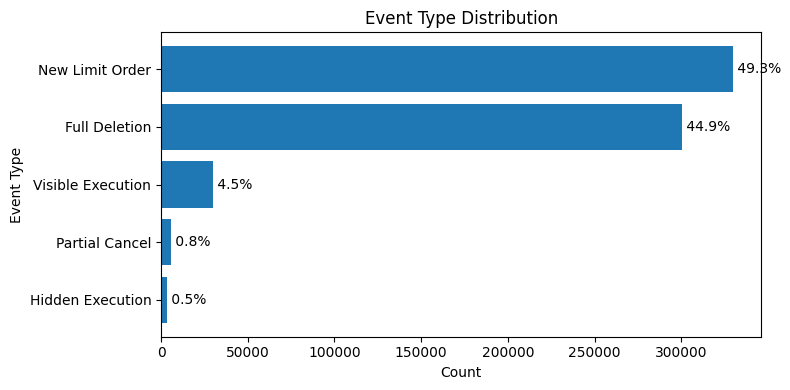

In [11]:
# event type distribution plot

plot_df = event_type_distribution.sort_values("count", ascending=True)

plt.figure(figsize=(8, 4))

plt.barh(plot_df["event_name"], plot_df["count"])

plt.title("Event Type Distribution")
plt.xlabel("Count")
plt.ylabel("Event Type")

for i, row in enumerate(plot_df.itertuples()):
    plt.text(row.count, i, f" {row.ratio_pct:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [ ]:
# LOBSTER fiyatları 10000 ile çarpılmış tamsayı olarak tutulur.
# Ham veriyi saklayıp, modelleme için kullanılacak kopyalarda fiyatları gerçek ölçeğe çeviriyoruz.

# LOBSTER prices are stored as integers multiplied by 10000.
# We keep the raw data unchanged and convert prices to the real scale in the copies used for modeling.
messages_data = messages.copy()
orderbook_data = orderbook.copy()

messages_data["price"] = messages_data["price"] / PRICE_SCALE

price_columns = [col for col in orderbook_data.columns if "price" in col]
orderbook_data[price_columns] = orderbook_data[price_columns] / PRICE_SCALE

print("Dönüşüm sonrası Level 1 satış fiyatı örnekleri:")
print(orderbook_data["ask_price_1"].head())

# Ölçeklenmiş veriler için kısa özet istatistikler
# Short summary statistics for the scaled data

summary_df = pd.concat(
    [
        messages_data[["time", "size", "price"]],
        orderbook_data[["ask_price_1", "bid_price_1", "ask_size_1", "bid_size_1"]]
    ],
    axis=1
)

raw_summary = summary_df.describe().T

display(raw_summary)

Dönüşüm sonrası Level 1 satış fiyatı örnekleri:
0    30.99
1    30.99
2    30.99
3    30.99
4    30.99
Name: ask_price_1, dtype: float64


,count,mean,std,min,25%,50%,75%,max
time,668765.0,45874.248562,7537.145129,34200.013994,39180.213674,45161.661476,53382.84477,57599.907797
size,668765.0,519.028556,928.238943,1.000000,100.000000,300.000000,700.00000,200000.000000
price,668765.0,30.550110,0.288589,29.970000,30.300000,30.520000,30.82000,31.210000
ask_price_1,668765.0,30.555106,0.286348,30.070000,30.310000,30.520000,30.82000,31.150000
bid_price_1,668765.0,30.542785,0.286017,30.060000,30.300000,30.500000,30.81000,31.130000
ask_size_1,668765.0,14957.418139,11316.313714,1.000000,8622.000000,13115.000000,18408.00000,216430.000000
bid_size_1,668765.0,14128.979836,11316.208196,1.000000,7766.000000,12030.000000,17522.00000,128500.000000


In [13]:
# verileri daha sonra da kullanabilmek için

# Fiyat ölçeği düzeltilmiş verileri sonraki notebookta kullanmak için kaydediyoruz.
messages_data.to_pickle("messages_data.pkl")
orderbook_data.to_pickle("orderbook_data.pkl")

print("messages_data.pkl kaydedildi.")
print("orderbook_data.pkl kaydedildi.")

print("messages_data shape :", messages_data.shape)
print("orderbook_data shape:", orderbook_data.shape)

messages_data.pkl kaydedildi.
orderbook_data.pkl kaydedildi.
messages_data shape : (668765, 6)
orderbook_data shape: (668765, 40)


In [14]:
# basic price and spread analysis

best_ask = orderbook_data["ask_price_1"]
best_bid = orderbook_data["bid_price_1"]

mid_price = (best_ask + best_bid) / 2
spread = best_ask - best_bid
relative_spread = spread / mid_price

print("Mid price summary:")
display(mid_price.describe())

print("\nSpread summary:")
display(spread.describe())

spread_tick = np.round(spread / TICK_SIZE)

print(f"\nMedian spread: ${spread.median():.4f}")
print(f"Median spread in ticks: {spread.median() / TICK_SIZE:.1f}")
print(f"Spread > 1 tick ratio: {(spread_tick > 1).mean():.3f}")

Mid price summary:


count    668765.000000
mean         30.548946
std           0.286175
min          30.065000
25%          30.305000
50%          30.510000
75%          30.815000
max          31.140000
dtype: float64


Spread summary:


count    668765.000000
mean          0.012320
std           0.004239
min           0.010000
25%           0.010000
50%           0.010000
75%           0.010000
max           0.050000
dtype: float64


Median spread: $0.0100
Median spread in ticks: 1.0
Spread > 1 tick ratio: 0.231


In [15]:
# price and spread features

orderbook_data["mid_price"] = mid_price
orderbook_data["spread"] = spread
orderbook_data["relative_spread"] = relative_spread

display(orderbook_data[[
    "ask_price_1",
    "bid_price_1",
    "mid_price",
    "spread",
    "relative_spread"
]].head())

,ask_price_1,bid_price_1,mid_price,spread,relative_spread
0,30.99,30.95,30.97,0.04,0.001292
1,30.99,30.95,30.97,0.04,0.001292
2,30.99,30.95,30.97,0.04,0.001292
3,30.99,30.95,30.97,0.04,0.001292
4,30.99,30.95,30.97,0.04,0.001292


In [16]:
# event type features

messages_data["is_new_order"] = (messages_data["type"] == 1).astype(int)
messages_data["is_partial_cancel"] = (messages_data["type"] == 2).astype(int)
messages_data["is_full_deletion"] = (messages_data["type"] == 3).astype(int)
messages_data["is_visible_execution"] = (messages_data["type"] == 4).astype(int)
messages_data["is_hidden_execution"] = (messages_data["type"] == 5).astype(int)
messages_data["is_execution"] = messages_data["type"].isin([4, 5]).astype(int)
messages_data["is_trading_halt"] = (messages_data["type"] == 7).astype(int)

messages_data["trade_size"] = np.where(
    messages_data["is_execution"] == 1,
    messages_data["size"],
    0
)

display(messages_data[[
    "type",
    "size",
    "is_new_order",
    "is_partial_cancel",
    "is_full_deletion",
    "is_visible_execution",
    "is_hidden_execution",
    "is_execution",
    "trade_size"
]].head())

,type,size,is_new_order,is_partial_cancel,is_full_deletion,is_visible_execution,is_hidden_execution,is_execution,trade_size
0,3,100,0,0,1,0,0,0,0
1,1,100,1,0,0,0,0,0,0
2,1,100,1,0,0,0,0,0,0
3,1,100,1,0,0,0,0,0,0
4,1,100,1,0,0,0,0,0,0


Toplam event: 668,765
Trade eventleri (type 4 + 5): 33,414 (5.00%)
Diğer eventler: 635,351 (95.00%)


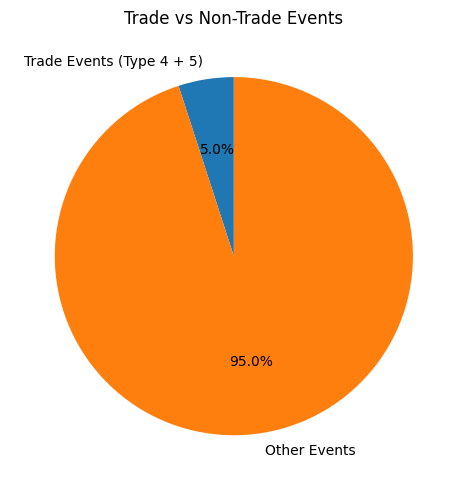

In [ ]:
# trade vs non-trade distribution

# Type 4 ve type 5 gerçek işlem gerçekleşmelerini temsil eder.
# Bu grafik, trade eventlerinin toplam eventler içindeki oranını gösterir.
# Trade event oranının düşük olması, high-frequency veride event dağılımının dengesiz olduğunu gösterir.

# Type 4 and Type 5 represent actual trade executions.
# This chart shows the share of trade events within all events.
# A low trade event ratio indicates that the event distribution is imbalanced in high-frequency data.
trade_total = int(messages_data["is_execution"].sum())
non_trade_total = len(messages_data) - trade_total
total_events = len(messages_data)

print(f"Toplam event: {total_events:,}")
print(f"Trade eventleri (type 4 + 5): {trade_total:,} ({trade_total / total_events * 100:.2f}%)")
print(f"Diğer eventler: {non_trade_total:,} ({non_trade_total / total_events * 100:.2f}%)")

plt.figure(figsize=(5, 5))

plt.pie(
    [trade_total, non_trade_total],
    labels=["Trade Events (Type 4 + 5)", "Other Events"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Trade vs Non-Trade Events")
plt.tight_layout()
plt.show()

In [18]:
# order book imbalance features

imbalance_data = {}

for depth in [1, 3, 5, 10]:

    ask_cols = [f"ask_size_{level}" for level in range(1, depth + 1)]
    bid_cols = [f"bid_size_{level}" for level in range(1, depth + 1)]

    ask_volume = orderbook_data[ask_cols].sum(axis=1)
    bid_volume = orderbook_data[bid_cols].sum(axis=1)

    imbalance_data[f"imbalance_{depth}"] = (
        (bid_volume - ask_volume) / (bid_volume + ask_volume)
    )

imbalance_df = pd.DataFrame(imbalance_data)

orderbook_data = pd.concat([orderbook_data, imbalance_df], axis=1)

display(orderbook_data[[
    "imbalance_1",
    "imbalance_3",
    "imbalance_5",
    "imbalance_10"
]].head())

,imbalance_1,imbalance_3,imbalance_5,imbalance_10
0,-0.853229,0.047528,0.043383,-0.454676
1,-0.853229,0.035166,0.032133,-0.456629
2,-0.853229,0.035166,0.043383,-0.456629
3,-0.853229,0.023093,0.032133,-0.458568
4,-0.853229,0.023093,0.021122,-0.460494


In [19]:
# top-5 depth features

ask_cols_5 = [f"ask_size_{level}" for level in range(1, 6)]
bid_cols_5 = [f"bid_size_{level}" for level in range(1, 6)]

orderbook_data["ask_depth_5"] = orderbook_data[ask_cols_5].sum(axis=1)
orderbook_data["bid_depth_5"] = orderbook_data[bid_cols_5].sum(axis=1)

display(orderbook_data[[
    "ask_depth_5",
    "bid_depth_5",
    "imbalance_5"
]].head())

,ask_depth_5,bid_depth_5,imbalance_5
0,4388,4786,0.043383
1,4488,4786,0.032133
2,4388,4786,0.043383
3,4488,4786,0.032133
4,4588,4786,0.021122


In [20]:
# order flow imbalance feature

old_bid_price = orderbook_data["bid_price_1"].shift(1)
old_bid_size = orderbook_data["bid_size_1"].shift(1)

old_ask_price = orderbook_data["ask_price_1"].shift(1)
old_ask_size = orderbook_data["ask_size_1"].shift(1)

bid_part = (
    (orderbook_data["bid_price_1"] >= old_bid_price).astype(float) * orderbook_data["bid_size_1"]
    - (orderbook_data["bid_price_1"] <= old_bid_price).astype(float) * old_bid_size
)

ask_part = (
    -((orderbook_data["ask_price_1"] <= old_ask_price).astype(float) * orderbook_data["ask_size_1"])
    + ((orderbook_data["ask_price_1"] >= old_ask_price).astype(float) * old_ask_size)
)

orderbook_data["ofi"] = (bid_part + ask_part).fillna(0)

display(orderbook_data[[
    "bid_price_1",
    "bid_size_1",
    "ask_price_1",
    "ask_size_1",
    "ofi"
]].head())

,bid_price_1,bid_size_1,ask_price_1,ask_size_1,ofi
0,30.95,300,30.99,3788,0.0
1,30.95,300,30.99,3788,0.0
2,30.95,300,30.99,3788,0.0
3,30.95,300,30.99,3788,0.0
4,30.95,300,30.99,3788,0.0


In [21]:
# minute information

messages_data["minute"] = (messages_data["time"] // 60).astype(int)

display(messages_data[["time", "minute"]].head())

print("Total minutes:", messages_data["minute"].nunique())
print("First minute:", messages_data["minute"].min())
print("Last minute:", messages_data["minute"].max())

,time,minute
0,34200.013994,570
1,34200.013994,570
2,34200.015248,570
3,34200.015442,570
4,34200.015789,570


Total minutes: 390
First minute: 570
Last minute: 959


In [22]:
# minute-level aggregation

event_data = pd.concat(
    [
        messages_data[[
            "minute",
            "size",
            "is_new_order",
            "is_partial_cancel",
            "is_full_deletion",
            "is_execution",
            "trade_size"
        ]],
        orderbook_data[[
            "mid_price",
            "spread",
            "relative_spread",
            "ask_depth_5",
            "bid_depth_5",
            "imbalance_1",
            "imbalance_3",
            "imbalance_5",
            "imbalance_10",
            "ofi"
        ]]
    ],
    axis=1
)

minute_agg = (
    event_data
    .groupby("minute")
    .agg(
        mid_open=("mid_price", "first"),
        mid_close=("mid_price", "last"),
        mid_mean=("mid_price", "mean"),

        spread_mean=("spread", "mean"),
        spread_std=("spread", "std"),
        spread_max=("spread", "max"),

        relative_spread_mean=("relative_spread", "mean"),

        ask_depth_mean=("ask_depth_5", "mean"),
        bid_depth_mean=("bid_depth_5", "mean"),

        imbalance_1_mean=("imbalance_1", "mean"),
        imbalance_3_mean=("imbalance_3", "mean"),
        imbalance_5_mean=("imbalance_5", "mean"),
        imbalance_10_mean=("imbalance_10", "mean"),

        ofi_sum=("ofi", "sum"),
        ofi_mean=("ofi", "mean"),
        ofi_std=("ofi", "std"),

        event_count=("mid_price", "count"),
        event_size_total=("size", "sum"),
        trade_volume=("trade_size", "sum"),

        n_new_order=("is_new_order", "sum"),
        n_partial_cancel=("is_partial_cancel", "sum"),
        n_full_deletion=("is_full_deletion", "sum"),
        n_execution=("is_execution", "sum")
    )
    .reset_index()
)

minute_agg["spread_std"] = minute_agg["spread_std"].fillna(0)
minute_agg["ofi_std"] = minute_agg["ofi_std"].fillna(0)

minute_agg["price_change"] = minute_agg["mid_close"] - minute_agg["mid_open"]

minute_agg["depth_imbalance"] = (
    (minute_agg["bid_depth_mean"] - minute_agg["ask_depth_mean"])
    / (minute_agg["bid_depth_mean"] + minute_agg["ask_depth_mean"])
)

minute_agg["execution_ratio"] = (
    minute_agg["n_execution"] / minute_agg["event_count"]
)

print("minute_agg shape:", minute_agg.shape)
print("Missing values:", minute_agg.isna().sum().sum())

display(minute_agg.head())

minute_agg shape: (390, 27)
Missing values: 0


,minute,mid_open,mid_close,mid_mean,spread_mean,spread_std,spread_max,relative_spread_mean,ask_depth_mean,bid_depth_mean,...,event_count,event_size_total,trade_volume,n_new_order,n_partial_cancel,n_full_deletion,n_execution,price_change,depth_imbalance,execution_ratio
0,570,30.970,31.030,31.006870,0.015846,0.006937,0.05,0.000511,27408.517256,9317.603538,...,2318,960665,100726,1153,8,819,338,0.060,-0.492590,0.145815
1,571,31.030,31.075,31.048728,0.013597,0.004949,0.03,0.000438,28868.341737,9319.614566,...,3570,1109998,113923,1699,43,1421,407,0.045,-0.511908,0.114006
2,572,31.075,31.055,31.073450,0.013584,0.004824,0.03,0.000437,13492.869452,12439.499347,...,1532,542227,33473,739,4,637,152,-0.020,-0.040620,0.099217
3,573,31.055,31.060,31.095780,0.014345,0.004958,0.02,0.000461,20437.152461,14443.600515,...,3109,1152591,78816,1518,25,1341,225,0.005,-0.171830,0.072371
4,574,31.060,31.005,30.993534,0.014124,0.004923,0.02,0.000456,14361.180905,19741.444891,...,2985,1025656,43411,1424,52,1331,178,-0.055,0.157767,0.059631


In [23]:
# minute-level return features

minute_agg["mid_return_1m"] = minute_agg["mid_close"].diff()
minute_agg["mid_log_return_1m"] = np.log(minute_agg["mid_close"]).diff()

minute_agg["mid_return_1m"] = minute_agg["mid_return_1m"].fillna(0)
minute_agg["mid_log_return_1m"] = minute_agg["mid_log_return_1m"].fillna(0)

display(minute_agg[[
    "minute",
    "mid_open",
    "mid_close",
    "price_change",
    "mid_return_1m",
    "mid_log_return_1m"
]].head())

,minute,mid_open,mid_close,price_change,mid_return_1m,mid_log_return_1m
0,570,30.970,31.030,0.060,0.000,0.000000
1,571,31.030,31.075,0.045,0.045,0.001449
2,572,31.075,31.055,-0.020,-0.020,-0.000644
3,573,31.055,31.060,0.005,0.005,0.000161
4,574,31.060,31.005,-0.055,-0.055,-0.001772


In [24]:
# minute-level summary

print("Minute-level dataset shape:", minute_agg.shape)
print("Minute range:", minute_agg["minute"].min(), "-", minute_agg["minute"].max())
print("Total minutes:", minute_agg["minute"].nunique())

summary_cols = [
    "mid_close",
    "spread_mean",
    "event_count",
    "trade_volume",
    "ofi_sum",
    "imbalance_1_mean",
    "depth_imbalance",
    "execution_ratio"
]

display(minute_agg[summary_cols].describe().T)

Minute-level dataset shape: (390, 29)
Minute range: 570 - 959
Total minutes: 390


,count,mean,std,min,25%,50%,75%,max
mid_close,390.0,30.550692,0.256076,30.065000,30.345000,30.490000,30.775000,31.075000
spread_mean,390.0,0.011774,0.001392,0.010000,0.010823,0.011490,0.012401,0.017249
event_count,390.0,1714.782051,1132.814661,182.000000,905.750000,1414.500000,2161.500000,6603.000000
trade_volume,390.0,27754.925641,40870.472004,0.000000,8164.000000,16871.500000,34857.250000,569818.000000
ofi_sum,390.0,-7533.751282,82769.397323,-304183.000000,-53622.000000,-5494.500000,33294.250000,349923.000000
imbalance_1_mean,390.0,-0.031438,0.196893,-0.580002,-0.163578,-0.023516,0.098614,0.501561
depth_imbalance,390.0,0.012350,0.099451,-0.511908,-0.039552,0.013317,0.067705,0.469229
execution_ratio,390.0,0.044591,0.020731,0.000000,0.030489,0.043501,0.055773,0.145815


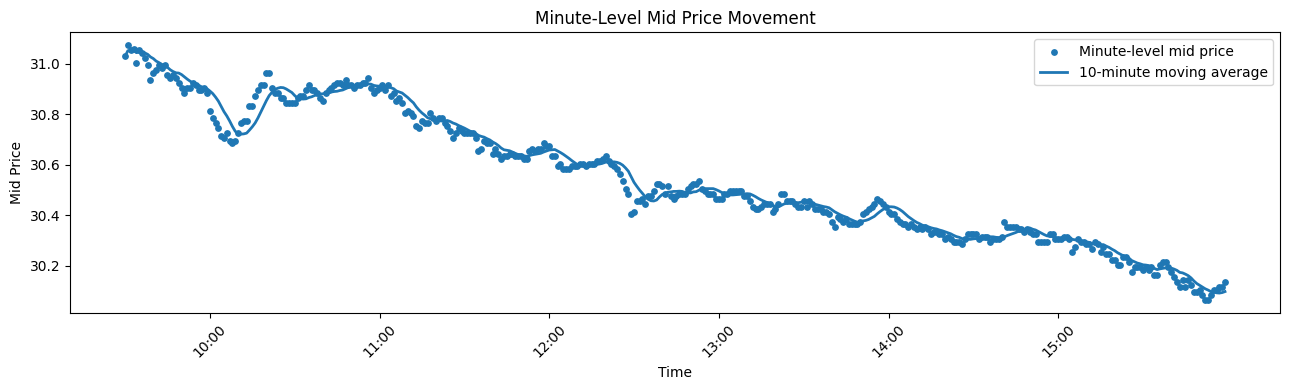

In [25]:
# minute-level mid price movement plot

minute_agg["hour"] = minute_agg["minute"] // 60
minute_agg["minute_of_hour"] = minute_agg["minute"] % 60

minute_agg["clock"] = (
    minute_agg["hour"].astype(str).str.zfill(2)
    + ":"
    + minute_agg["minute_of_hour"].astype(str).str.zfill(2)
)

minute_agg["mid_ma10"] = (
    minute_agg["mid_close"]
    .rolling(window=10, min_periods=1)
    .mean()
)

x_values = np.arange(len(minute_agg))

hour_rows = minute_agg[
    minute_agg["clock"].str.endswith(":00")
]

plt.figure(figsize=(13, 4))

plt.scatter(
    x_values,
    minute_agg["mid_close"],
    s=15,
    label="Minute-level mid price"
)

plt.plot(
    x_values,
    minute_agg["mid_ma10"],
    linewidth=2,
    label="10-minute moving average"
)

plt.xticks(
    hour_rows.index,
    hour_rows["clock"],
    rotation=45
)

plt.title("Minute-Level Mid Price Movement")
plt.xlabel("Time")
plt.ylabel("Mid Price")
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
# save minute-level features

minute_agg.to_pickle("minute_features.pkl")
minute_agg.to_csv("minute_features.csv", index=False)

print("minute_features.pkl kaydedildi.")
print("minute_features.csv kaydedildi.")

print("minute_features shape:", minute_agg.shape)
print("columns:", minute_agg.shape[1])

minute_features.pkl kaydedildi.
minute_features.csv kaydedildi.
minute_features shape: (390, 33)
columns: 33


In [ ]:
# What was done in the first notebook:

# 1. Required libraries were loaded.

# 2. Seed settings were applied for reproducibility.

# 3. LOBSTER data files and basic constants were defined:

#    * `PRICE_SCALE`
#    * `LEVELS`
#    * `TICK_SIZE`

# 4. The `message` and `orderbook` files were read.

# 5. Basic data quality checks were performed:

#    * row count matching
#    * duplicate row check
#    * timestamp order check
#    * bid ≤ ask check
#    * locked market check
#    * positive price check
#    * missing value check
#    * dummy price check
#    * trading halt check

# 6. Event type and direction distributions were examined.

# 7. The event type distribution chart was plotted.

# 8. LOBSTER prices were converted to the real scale.

# 9. Short summary statistics were generated for the scaled data.

# 10. The scaled `messages_data` and `orderbook_data` were saved as pickle files.

# 11. Basic price features were created:

# * `mid_price`
# * `spread`
# * `relative_spread`

# 12. Event type features were created:

# * new order
# * partial cancellation
# * full deletion
# * visible execution
# * hidden execution
# * execution
# * trade size

# 13. The trade / non-trade distribution was examined.

# 14. Order book imbalance features were created:

# * `imbalance_1`
# * `imbalance_3`
# * `imbalance_5`
# * `imbalance_10`

# 15. Top-5 depth features were created:

# * `ask_depth_5`
# * `bid_depth_5`

# 16. OFI was calculated.

# 17. Event-level data was matched with minute information.

# 18. Event-level data was converted into a minute-level table.

# 19. Minute-level features were created:

# * price summaries
# * spread summaries
# * depth summaries
# * imbalance summaries
# * OFI summaries
# * event/trade counts
# * execution ratio
# * depth imbalance

# 20. Minute-level return features were added:

# * `mid_return_1m`
# * `mid_log_return_1m`

# 21. A short minute-level summary and a price movement chart were created.

# 22. The final minute-level data was saved:

# * `minute_features.pkl`
# * `minute_features.csv`